# 05 · Outcomes, duration and composition

Research question: do changes in aggregate finish rates survive division adjustment? Finishes mean KO/TKO, including doctor stoppages, or submission. Result status overrides method for draws and no contests.

In [1]:
from pathlib import Path
import sys
import io
import pandas as pd
import numpy as np
from IPython.display import display, Image
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data' / 'raw').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.data_loader import load_raw, profile_sources, verify_raw, TABLES
from src.pipeline import prepare
from src.analysis import *
from src.visualization import *
def show(figure):
    buffer = io.BytesIO()
    figure.savefig(buffer, format='png', bbox_inches='tight')
    display(Image(data=buffer.getvalue()))
    plt.close(figure)

## Prepare cohort

Every outcome remains in the denominator of method shares.

In [2]:
data = prepare(save=False)
fights, appearances = cohort(data)
print(f"Cohort: {len(fights):,} fights, {fights.event_id.nunique():,} events, {appearances.fighter_id.nunique():,} fighters")
print(f"Date range: {fights.event_date.min():%Y-%m-%d} to {fights.event_date.max():%Y-%m-%d}")

Cohort: 8,820 fights, 783 events, 2,735 fighters
Date range: 1994-03-11 to 2026-08-08


## Victory methods

KO versus TKO is not separately recoverable from the combined source category. Do not invent that split.

,result_status,method,outcome_group,fights,share_all_fights
0,draw,Decision - Majority,Draw,38,0.004308
1,draw,Decision - Split,Draw,17,0.001927
2,draw,Decision - Unanimous,Draw,7,0.000794
3,draw,Other,Draw,2,0.000227
4,draw,Overturned,Draw,1,0.000113
5,no_contest,Could Not Continue,No contest,33,0.003741
6,no_contest,Overturned,No contest,58,0.006576
7,win,DQ,Other,23,0.002608
8,win,Decision - Majority,Decision,66,0.007483
9,win,Decision - Split,Decision,811,0.091950


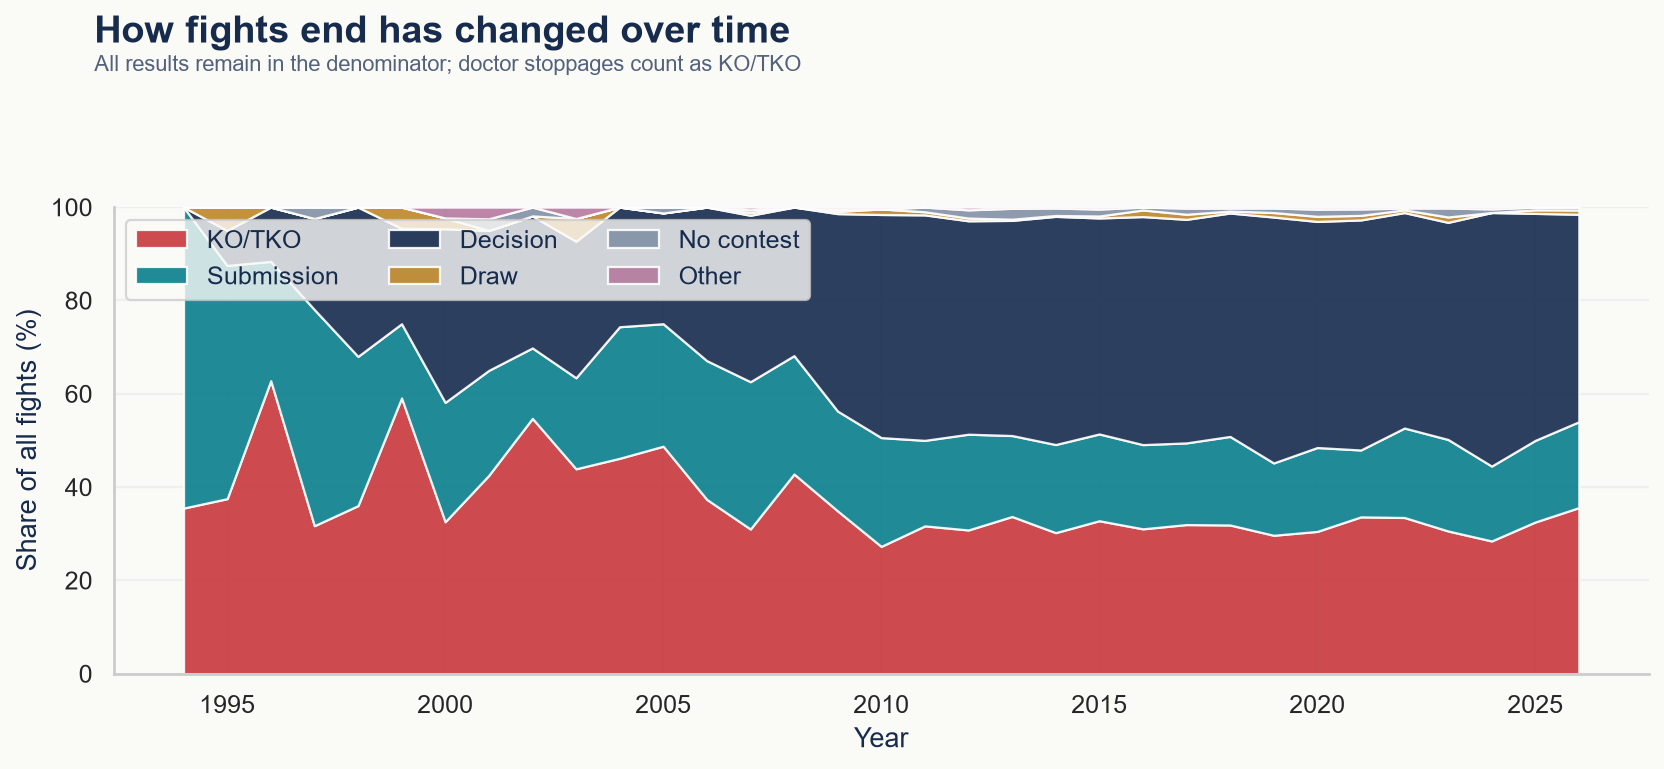

Finish share: 0.5218820861678004


In [3]:
tables = export_outcomes(data)
display(tables['outcome_methods'])
show(outcome_chart(fights))
print('Finish share:', fights.is_finish.mean())

## A composition reversal

Compare full 2010–2019 and 2020–2025 periods. Standardization uses fixed pooled weights over shared divisions with at least 50 fights in each period.

In [4]:
adjustment = composition_adjustment(fights)
display(adjustment)
print('Observed change (percentage points):', adjustment.all_division_decision_rate.diff().iloc[-1]*100)
print('Standardized change (percentage points):', adjustment.standardized_decision_rate.diff().iloc[-1]*100)

,period,all_division_decision_rate,standardized_decision_rate,shared_divisions,retained_fights,all_fights
0,2010–2019,0.482364,0.489434,11,4167,4196
1,2020–2025,0.489285,0.478160,11,2962,3033


Observed change (percentage points): 0.692038042291071
Standardized change (percentage points): -1.1274637216847294


## Duration and scheduled exposure

Title fights often have longer schedules. Show schedule-stratified duration before comparing title status.

In [5]:
display(tables['title_duration'])
display(fights.groupby(['weight_class','outcome_group']).fight_duration_seconds.agg(['count','mean','median']).head(30))
display(tables['ending_rounds'])

,title_fight,scheduled_rounds,fights,minutes
0,0,1.0,52,3.809936
1,0,2.0,99,6.917845
2,0,3.0,7743,10.247477
3,0,4.0,9,11.070370
4,0,5.0,405,14.436831
5,1,1.0,1,3.016667
6,1,2.0,11,14.268182
7,1,3.0,55,9.975758
8,1,4.0,34,10.320098
9,1,5.0,380,15.953816


count         mean  median
weight_class      outcome_group                            
Bantamweight      Decision         412   936.407767   900.0
                  Draw               7   900.000000   900.0
                  KO/TKO           203   374.103448   292.0
                  No contest        15   453.000000   457.0
                  Other              1  1169.000000  1169.0
                  Submission       156   430.903846   415.0
Catch Weight      Decision          39   961.538462   900.0
                  Draw               1   900.000000   900.0
                  KO/TKO            23   404.739130   321.0
                  No contest         1   419.000000   419.0
                  Submission        18   355.222222   287.0
Featherweight     Decision         457   942.013129   900.0
                  Draw               8   900.000000   900.0
                  KO/TKO           257   359.832685   284.0
                  No contest         8   392.750000   370.0
                  Other              1    25.000000    25.0
                  Submission       146   386.924658   364.5
Flyweight         Decision         224   945.531250   900.0
                  Draw               3  1100.000000   900.0
                  KO/TKO           101   388.257426   326.0
                  No contest         4   401.250000   316.0
                  Other              1   472.000000   472.0
                  Submission        91   434.956044   406.0
Heavyweight       Decision         246   947.373984   900.0
                  Draw               6  1000.000000   900.0
                  KO/TKO           403   341.660050   278.0
                  No contest        11   473.909091   359.0
                  Other              3   297.333333   269.0
                  Submission       115   287.808696   219.0
Light Heavyweight Decision         270   959.011111   900.0

,outcome_group,finish_round,fights
0,Decision,1,6
1,Decision,2,24
2,Decision,3,3712
3,Decision,5,296
4,Draw,2,4
5,Draw,3,54
6,Draw,5,7
7,KO/TKO,1,1560
8,KO/TKO,2,857
9,KO/TKO,3,414


## How long are bouts still active?

This empirical survivor curve counts every ending, including decisions, as an endpoint. It is not a Kaplan–Meier estimate of finish risk with decisions censored.

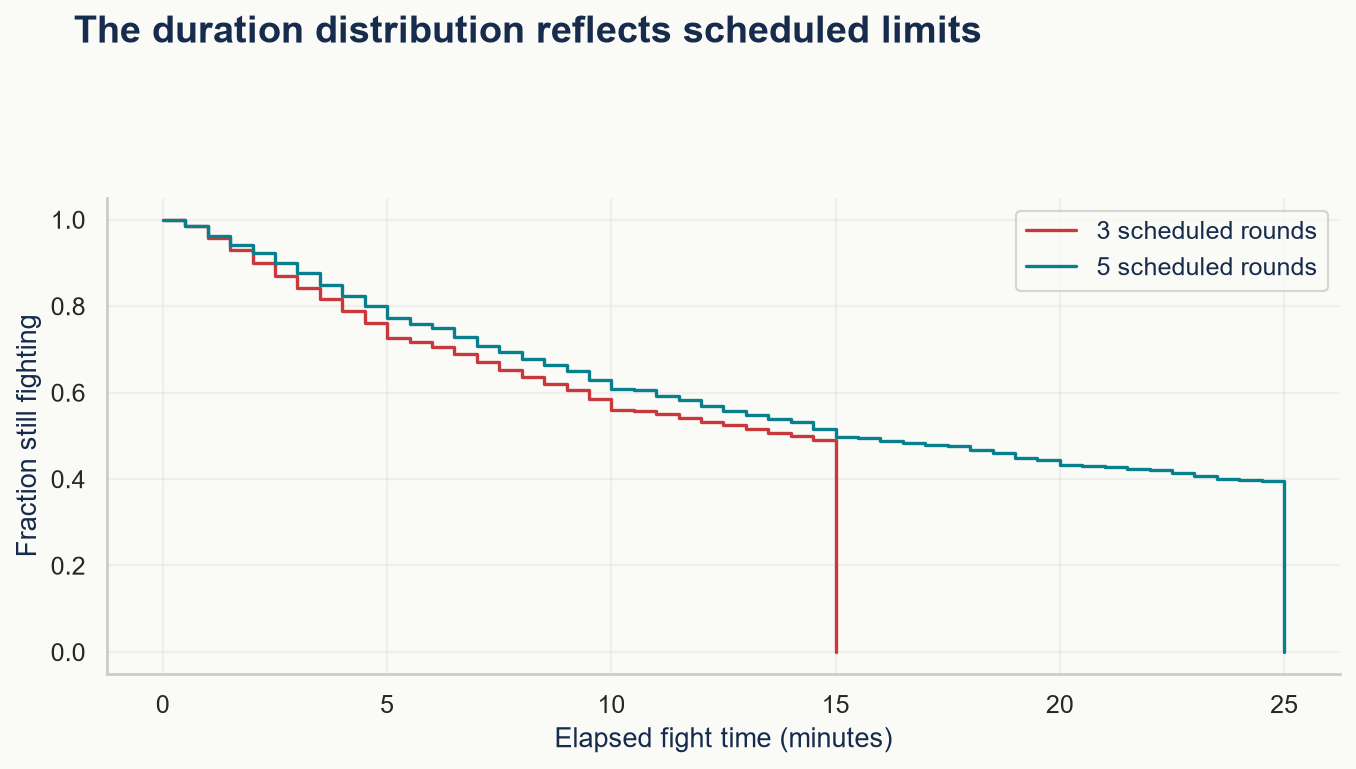

In [6]:
curve = duration_curve(fights)
style()
fig, ax = plt.subplots(figsize=(9,5))
for schedule, rows in curve.groupby('scheduled_rounds'):
    ax.step(rows.seconds/60, rows.still_fighting, where='post', label=f'{int(schedule)} scheduled rounds')
ax.set(xlabel='Elapsed fight time (minutes)', ylabel='Fraction still fighting')
ax.legend(); show(finish(fig,'The duration distribution reflects scheduled limits'))